# Popularity Baseline — Benchmark

Antes de comparar modelos de recomendación más potentes conviene tener un punto de referencia trivial: si un sistema personalizado no logra superar a una recomendación que **ignora completamente al usuario**, entonces no está aportando nada. Eso es exactamente lo que se construyó en este notebook.

## ¿Qué hace este modelo?

El recomendador de popularidad tiene una sola regla: **devolver las películas más populares del catálogo**, en el mismo orden, a todos los usuarios. La única personalización consistió en omitir las películas que el usuario ya había calificado, para no recomendarle algo que ya conocía.

La popularidad se midió con el **TMDb weighted rating**, almacenado en la columna `score` de `movies_benchmark.csv`. Esa columna se construyó con la fórmula clásica de IMDb:

$$
\mathrm{WR} \;=\; \frac{v}{v+m}\cdot R \;+\; \frac{m}{v+m}\cdot C
$$

donde `v` es el número de votos de la película, `R` su promedio, `C` la media global del catálogo y `m` el percentil 90 del conteo de votos. La fórmula combina el promedio individual con el promedio global ponderado por la cantidad de votos: una película con muchas reseñas y promedio alto sube al tope, mientras que una con tres reseñas perfectas se queda donde debería. Es una versión "bayesiana" del promedio.

Se heredó esa columna del catálogo `movies_final.csv` del dataset original.

## Glosario

**Relevancia** — una película se considera relevante para el usuario si le puso **rating ≥ 4.0** (pensado para enfocar la evaluación en lo que al usuario *realmente* le gustó).

**Métricas de MovieLens** (full-catalog ranking sobre los ~4k items del catálogo benchmark).

* **Precision@K** — De las K recomendaciones, qué fracción fue relevante. *Sensible a k*

$$\text{Precision@K} = \frac{|\{\text{recomendados en top-K}\} \cap \{\text{relevantes}\}|}{K}$$

* **HR@K (Hit Rate)** — Proporción de usuarios para los que al menos un ítem relevante aparece en el top-K. Es binaria por usuario: 1 si hay al menos un acierto, 0 si no.

$$\text{HR@K} = \frac{1}{|U|} \sum_{u \in U} \mathbb{1}\left[\text{top-K}(u) \cap \text{relevantes}(u) \neq \emptyset\right]$$

* **Recall@K normalizado** — Fracción de los ítems relevantes recuperados, normalizada por el máximo alcanzable en K posiciones. Corrige el problema estructural del recall clásico cuando el usuario tiene más relevantes de los que caben en K.

$$\text{Recall@K}_{\text{norm}} = \frac{|\{\text{recomendados en top-K}\} \cap \{\text{relevantes}\}|}{\min(K,\; |\text{relevantes}|)}$$

* **NDCG@K** — *Normalized Discounted Cumulative Gain*. Considera el **orden**: poner un relevante en posición 1 vale más que ponerlo en posición 10. Penalización logarítmica.

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}, \qquad \text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

donde $\text{rel}_i = 1$ si el ítem en posición $i$ es relevante (0 en caso contrario), y $\text{IDCG@K}$ es el DCG del ranking perfecto.

* **Diversity@K** — Disimilitud media entre todos los pares del top-K.

$$\text{Diversity@K} = \frac{1}{\binom{K}{2}} \sum_{i < j} \left(1 - \text{cosine\_sim}(r_i, r_j)\right)$$

Cerca de 0 = lista monotemática; cerca de 1 = lista variada.

* **Novelty@K** — Premia a hacer recomendaciones de pelíuclas no tan populares

$$\text{Novelty@K} = \frac{1}{K} \sum_{i=1}^{K} \left(1 - \text{pop}(r_i)\right)$$

Cerca de 0 = solo blockbusters; cerca de 1 = películas de nicho.

* **Coverage** — Fracción del catálogo recomendado al menos una vez entre todos los usuarios.

$$\text{Coverage} = \frac{\left|\bigcup_{u} \text{top-K}(u)\right|}{|\text{catálogo}|}$$

Mide si el modelo explora el catálogo o se concentra en un subconjunto pequeño.

## Protocolo de evaluación

Para todos los modelos se adoptaron dos protocolos de evaluación distintos, uno por cada dataset, adaptados a las características y tamaño de cada uno.

### Dataset de Benchmark (~6,000 usuarios, ~3,800 películas)

Se utilizó **full-catalog evaluation**: para cada usuario del test, se dividieron sus ratings de forma temporal 80/20. El modelo generó un ranking real sobre las ~3,800 películas del catálogo completo (excluyendo las ya vistas en train). Se midieron las **6 métricas** del glosario (*Precision, HR, Recall normalizado, NDCG, Diversity, Novelty y Coverage*) sobre el top-K de cada usuario.

**¿Por qué full-catalog?** Porque es la única forma honesta de medir métricas **beyond-accuracy** (*Diversity, Novelty, Coverage*)

### Dataset de Survey (~119 usuarios, ~87 películas)

Se utilizó **sampled leave-one-out (LOO)** con **HR@K y NDCG@K** como métricas. Para cada usuario se eligió **1 positivo aleatorio** como held-out. En cada fold, el modelo rankeó el held-out contra 99 negativos muestreados del catálogo completo (~3,800) y se midió si el positivo quedó en el top-K (HR) y en qué posición (NDCG).

**¿Por qué sampled LOO y no full-catalog?** Sampled evaluation reduce el problema a "de 100 candidatos (1 positivo + 99 negativos del catálogo completo), ¿el modelo logra posicionar al positivo en el top-K?". Esto da una señal limpia y comparable entre modelos sin exigirles rankear miles de ítems sobre los que no aprendieron nada.

El train de cada fold de Survey incluyó **todos los ratings de todos los usuarios válidos** (no solo los del usuario evaluado), preservando la matriz completa de interacciones que CF necesita para aprender embeddings.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import ml.config as cfg
from ml.evaluation import notebook_utils as nu
from ml.evaluation.splits import movielens_split
from ml.models.popularity import PopularityRecommender

K = 10
movies_df = pd.read_csv(cfg.MOVIES_PATH)
cosine_sim = cfg.load_cosine_sim()
popularity = cfg.load_popularity()
N_ITEMS = cfg.catalog_size()
print(f"catalog_size = {N_ITEMS:,}  |  K = {K}")

catalog_size = 3,830  |  K = 10


## 1. Top-10 películas más populares del catálogo

A continuación se mostrarán las diez películas con el mayor `score` del catálogo benchmark. Esta es **la única lista** que el modelo recomendará a todos los usuarios (si un usuario ya vio alguna película, está no se recomendará y en su lugar se le recomendará la siguiente con mayor popularidad).

In [2]:
from tabulate import tabulate

top10 = (
    movies_df.sort_values("score", ascending=False)
    .head(10)
    [["title", "vote_count", "vote_average", "score"]]
    .reset_index(drop=True)
)
rows = []
for i, r in top10.iterrows():
    rows.append([i + 1, r["title"], f"{r['vote_count']:,}", f"{r['score']:.3f}"])
print(tabulate(rows, headers=["#", "Título", "Votos", "Score WR"], tablefmt="fancy_grid"))

╒═════╤═══════════════════════════════════════════════════╤═════════╤════════════╕
│   # │ Título                                            │   Votos │   Score WR │
╞═════╪═══════════════════════════════════════════════════╪═════════╪════════════╡
│   1 │ The Dark Knight                                   │  35,465 │      8.298 │
├─────┼───────────────────────────────────────────────────┼─────────┼────────────┤
│   2 │ Interstellar                                      │  39,350 │      8.268 │
├─────┼───────────────────────────────────────────────────┼─────────┼────────────┤
│   3 │ The Lord of the Rings: The Return of the King     │  26,305 │      8.21  │
├─────┼───────────────────────────────────────────────────┼─────────┼────────────┤
│   4 │ Inception                                         │  38,982 │      8.208 │
├─────┼───────────────────────────────────────────────────┼─────────┼────────────┤
│   5 │ Fight Club                                        │  31,765 │      8.172 │
├───

## 2. Evaluación

In [3]:
train, test = movielens_split(cfg.RATINGS_PATH)
print(f"Benchmark  train={len(train):,}  test_positives={len(test):,}  "
      f"users={train['user_id'].nunique():,}")

Benchmark  train=797,809  test_positives=108,298  users=6,000


### Evaluación sobre el Benchmark (full-catalog, K=10)

### Métricas Benchmark — K=10

╒═════════════╤══════════╕
│ Métrica     │    Valor │
╞═════════════╪══════════╡
│ precision   │    0.114 │
├─────────────┼──────────┤
│ recall      │    0.121 │
├─────────────┼──────────┤
│ ndcg        │    0.135 │
├─────────────┼──────────┤
│ diversity   │    0.432 │
├─────────────┼──────────┤
│ novelty     │    0.109 │
├─────────────┼──────────┤
│ coverage    │    0.013 │
├─────────────┼──────────┤
│ n_evaluated │ 5987     │
├─────────────┼──────────┤
│ n_skipped   │    0     │
╘═════════════╧══════════╛


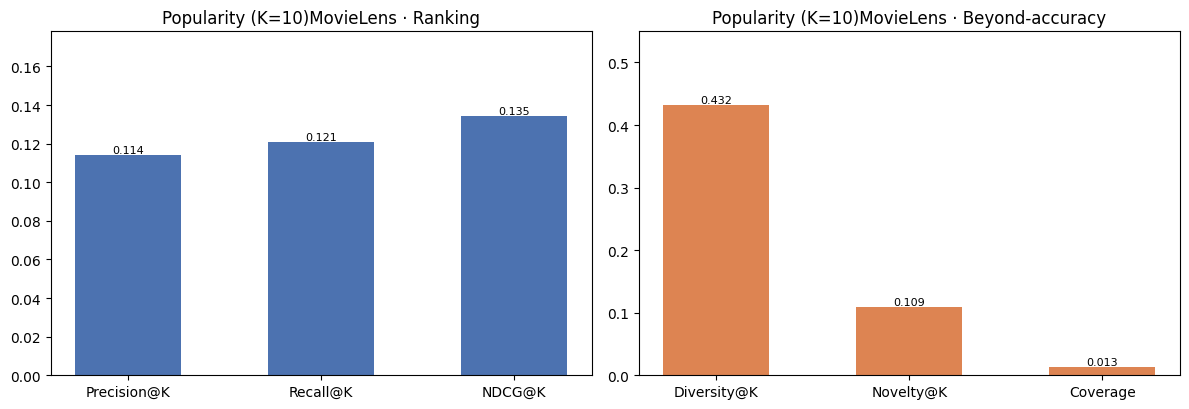

In [4]:
model = PopularityRecommender(cfg.MOVIES_PATH)
results = nu.evaluate_movielens(
    model=model,
    train=train,
    test=test,
    k=K,
    cosine_sim=cosine_sim,
    popularity=popularity,
    n_items=N_ITEMS,
)
from IPython.display import Markdown, display
display(Markdown(f'### Métricas Benchmark — K={K}'))
nu.print_metrics(results)

nu.plot_dataset_metrics(movielens=results, title_prefix=f"Popularity (K={K})")

**Benchmark** — Precision@10 y Recall@10 normalizado quedan moderados: el popularity baseline sí es capaz de acertar un positivo cuando las películas que le gustan al usuario son, simplemente, películas populares. NDCG@10 muestra el mismo patrón en escala menor. Diversity queda relativamente alto (~0.43) porque el top-10 es una mezcla de géneros distintos; **Novelty es muy baja (~0.1)**, exactamente lo esperado de un modelo que solo recomienda blockbusters; y **Coverage es trivial** (~1%), porque el modelo recomienda siempre las mismas ~30-40 películas entre todos los usuarios.

## 5. Evaluación Survey (sampled LOO)

Leave-one-out con 1 positivo oculto + 99 negativos muestreados, reportando **HR@K** y **NDCG@K**.

Los números de Survey son sistemáticamente más altos que los de MovieLens porque se rankean solo 100 candidatos vs ~3.7k. No son comparables directamente entre datasets, pero sí son comparables **entre modelos** en el mismo dataset.

Survey folds: 118


### Métricas Survey — K=10

╒═════════════╤═════════╕
│ Métrica     │   Valor │
╞═════════════╪═════════╡
│ hr          │   0.873 │
├─────────────┼─────────┤
│ ndcg        │   0.618 │
├─────────────┼─────────┤
│ n_evaluated │ 118     │
├─────────────┼─────────┤
│ n_skipped   │   0     │
╘═════════════╧═════════╛


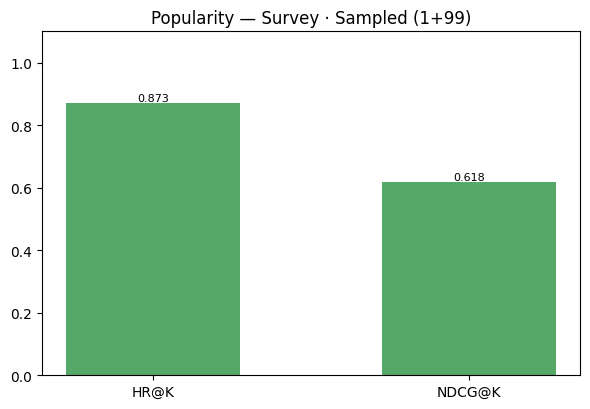

In [5]:
from ml.evaluation.splits import survey_split_sampled

sv_folds = survey_split_sampled(
    nu.RATINGS_SURVEY_PATH, cfg.MOVIES_PATH, n_negatives=99, seed=42,
)
print(f"Survey folds: {len(sv_folds)}")

survey_results = nu.evaluate_survey(
    model_factory=lambda: PopularityRecommender(cfg.MOVIES_PATH),
    folds=sv_folds,
    k=K,
    n_items=N_ITEMS,
)
display(Markdown(f'### Métricas Survey — K={K}'))
nu.print_metrics(survey_results)
nu.plot_survey_metrics(survey_results, title_prefix=f'Popularity — ')

**Survey** — HR@10 y NDCG@10 salieron bastante altas, pero es normal debido a que las películas que se le mostraton a los usuarios fueron las 100 películas más populares del conjunto de 5,000 películas, por lo que al recomendarle populares, siempre se acertará.

## 4. Ejemplos de recomendaciones

Para dar una intuición concreta de cómo se ven las recomendaciones del popularity baseline, se tomaron 3 usuarios del test set y se les generó su top-10. Como el modelo es no-personalizado, los top-10 son prácticamente idénticos entre ellos — solo varía cuáles películas se excluyen por ya haber sido vistas.

In [6]:
from tabulate import tabulate

movies_df = pd.read_csv(cfg.MOVIES_PATH)
lookup = {int(r.movie_id): (r.title, str(r.release_date)[:4] if pd.notna(getattr(r, 'release_date', None)) else '—')
          for r in movies_df.itertuples(index=False)}

model = PopularityRecommender(cfg.MOVIES_PATH)
model.fit(train)

rng_ex = np.random.default_rng(42)
sample_users = rng_ex.choice(test['user_id'].unique(), size=3, replace=False).tolist()
for uid in sample_users:
    display(Markdown(f'### Usuario {uid}'))
    recs = model.recommend(int(uid), n=K)
    rows = []
    for rank, mid in enumerate(recs, 1):
        title, year = lookup.get(int(mid), (f'<idx {mid}>', '—'))
        rows.append([rank, title, year])
    print(tabulate(rows, headers=['#', 'Título', 'Año'], tablefmt='fancy_grid'))


### Usuario 3927

╒═════╤═══════════════════════════════════════════════╤═══════╕
│   # │ Título                                        │   Año │
╞═════╪═══════════════════════════════════════════════╪═══════╡
│   1 │ The Lord of the Rings: The Return of the King │  2003 │
├─────┼───────────────────────────────────────────────┼───────┤
│   2 │ Fight Club                                    │  1999 │
├─────┼───────────────────────────────────────────────┼───────┤
│   3 │ Parasite                                      │  2019 │
├─────┼───────────────────────────────────────────────┼───────┤
│   4 │ Spirited Away                                 │  2001 │
├─────┼───────────────────────────────────────────────┼───────┤
│   5 │ The Green Mile                                │  1999 │
├─────┼───────────────────────────────────────────────┼───────┤
│   6 │ Se7en                                         │  1995 │
├─────┼───────────────────────────────────────────────┼───────┤
│   7 │ Avengers: Infinity War          

### Usuario 535

╒═════╤═══════════════════════════════════════╤═══════╕
│   # │ Título                                │   Año │
╞═════╪═══════════════════════════════════════╪═══════╡
│   1 │ The Dark Knight                       │  2008 │
├─────┼───────────────────────────────────────┼───────┤
│   2 │ Interstellar                          │  2014 │
├─────┼───────────────────────────────────────┼───────┤
│   3 │ Inception                             │  2010 │
├─────┼───────────────────────────────────────┼───────┤
│   4 │ Fight Club                            │  1999 │
├─────┼───────────────────────────────────────┼───────┤
│   5 │ Parasite                              │  2019 │
├─────┼───────────────────────────────────────┼───────┤
│   6 │ The Green Mile                        │  1999 │
├─────┼───────────────────────────────────────┼───────┤
│   7 │ The Lord of the Rings: The Two Towers │  2002 │
├─────┼───────────────────────────────────────┼───────┤
│   8 │ Avengers: Infinity War                │ 

### Usuario 4641

╒═════╤═══════════════════════════════════════════════════╤═══════╕
│   # │ Título                                            │   Año │
╞═════╪═══════════════════════════════════════════════════╪═══════╡
│   1 │ Interstellar                                      │  2014 │
├─────┼───────────────────────────────────────────────────┼───────┤
│   2 │ The Lord of the Rings: The Return of the King     │  2003 │
├─────┼───────────────────────────────────────────────────┼───────┤
│   3 │ Fight Club                                        │  1999 │
├─────┼───────────────────────────────────────────────────┼───────┤
│   4 │ The Lord of the Rings: The Fellowship of the Ring │  2001 │
├─────┼───────────────────────────────────────────────────┼───────┤
│   5 │ Spirited Away                                     │  2001 │
├─────┼───────────────────────────────────────────────────┼───────┤
│   6 │ Avengers: Infinity War                            │  2018 │
├─────┼─────────────────────────────────────────

## 6. Persistencia del modelo

Se guarda el modelo entrenado a disco para poder reutilizarlo en notebooks posteriores (comparación final, modelo híbrido) sin necesidad de re-entrenar.

In [7]:
SAVED_DIR = Path('..') / 'models' / 'saved'
SAVED_DIR.mkdir(parents=True, exist_ok=True)

model.save(SAVED_DIR / 'popularity.pkl')
print(f'Modelo guardado en: {SAVED_DIR / "popularity.pkl"}')

Modelo guardado en: ../models/saved/popularity.pkl
